# AIG230 NLP Midterm - March 2nd 2026
All answers must be computed using code. Provide numeric outputs and short interpretations.
## Instructions
- You must compute answers using code.
- Many questions require numeric answers.
- Interpretation must be supported by computed results.

In [2]:
import nltk, string, math, random, re
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
print('All imports successful')
# print(f'TensorFlow version: {tf.__version__}')

All imports successful


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\stada\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\stada\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\stada\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load Corpora

In [3]:
# Load corpora
with open('corpus_tech_ai_labeled.csv', 'r', encoding='utf-8') as f:
    tech_text = f.read()

with open('corpus_movie_reviews_labeled.csv', 'r', encoding='utf-8') as f:
    review_text = f.read()

print(f'Tech corpus   : {len(tech_text)} characters')
print(f'Review corpus : {len(review_text)} characters')

Tech corpus   : 13049 characters
Review corpus : 4044 characters


## Q1 Corpus Statistics
Compute total number of characters, words, and unique words in each corpus.
What is the vocabulary size of each corpus?

In [7]:
import re

def tokenize_corpus(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)  # remove punctuation
    words = text.split()
    return words

# Tokenize both corpora
tech_words = tokenize_corpus(tech_text)
review_words = tokenize_corpus(review_text)


# Total characters (including newlines/spaces as they exist in the loaded text)
tech_char_count = len(tech_text)
review_char_count = len(review_text)

# Total words
tech_word_count = len(tech_words)
review_word_count = len(review_words)

# Unique words + vocabulary size (same thing here)
tech_unique_words = set(tech_words)
review_unique_words = set(review_words)

tech_unique_count = len(tech_unique_words)
review_unique_count = len(review_unique_words)

print(f"Tech corpus:")
print(f"  Total characters : {tech_char_count}")
print(f"  Total words      : {tech_word_count}")
print(f"  Unique words     : {tech_unique_count}")
print(f"  Vocabulary size  : {tech_unique_count}")

print(f"\nReview corpus:")
print(f"  Total characters : {review_char_count}")
print(f"  Total words      : {review_word_count}")
print(f"  Unique words     : {review_unique_count}")
print(f"  Vocabulary size  : {review_unique_count}")

Tech corpus:
  Total characters : 13049
  Total words      : 1668
  Unique words     : 149
  Vocabulary size  : 149

Review corpus:
  Total characters : 4044
  Total words      : 638
  Unique words     : 85
  Vocabulary size  : 85


### Answer Q1:


Tech corpus:

  Total characters : 13049

  Total words      : 1668

  Unique words     : 149

  Vocabulary size  : 149

----

Review corpus:

  Total characters : 4044

  Total words      : 638

  Unique words     : 85

  Vocabulary size  : 85

  
----


## Q2 Lexical Diversity
Tokenize and lowercase both corpora. Compute type-token ratio.
Which corpus is more lexically diverse?

In [9]:
# Q2 - Step 1: Compute Type-Token Ratio (TTR)

# we lowercase the corpuses in Q1


tech_ttr = tech_unique_count / tech_word_count
review_ttr = review_unique_count / review_word_count


print(f"Tech corpus TTR   : {tech_ttr:.4f}")
print(f"Review corpus TTR : {review_ttr:.4f}")

Tech corpus TTR   : 0.0893
Review corpus TTR : 0.1332


### Answer Q2:


Both corpora were lowercased and tokenized.
The Type-Token Ratio (TTR) for the tech corpus is 0.0893, while for the review corpus it is 0.1332.
Since the review corpus has a higher TTR, it is more lexically diverse.

## Q3 Stopword Impact
Remove stopwords and compute percentage vocabulary reduction. How much does vocabulary size decrease (percentage) for each corpus?

In [15]:

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS



stopwords = set(ENGLISH_STOP_WORDS)

# Remove stopwords from token lists
tech_words_no_stop = [w for w in tech_words if w not in stopwords]
review_words_no_stop = [w for w in review_words if w not in stopwords]

# Compute new vocabularies
tech_vocab_no_stop = set(tech_words_no_stop)
review_vocab_no_stop = set(review_words_no_stop)

print("Original Tech vocab size   :", tech_unique_count)
print("Tech vocab (no stopwords)  :", len(tech_vocab_no_stop))

print("Ratio:", 100 * (1 - len(tech_vocab_no_stop) / tech_unique_count), "% reduction")

print("\nOriginal Review vocab size :", review_unique_count)
print("Review vocab (no stopwords):", len(review_vocab_no_stop))
print("Ratio:", 100 * (1 - len(review_vocab_no_stop) / review_unique_count), "% reduction")


Original Tech vocab size   : 149
Tech vocab (no stopwords)  : 134
Ratio: 10.067114093959727 % reduction

Original Review vocab size : 85
Review vocab (no stopwords): 66
Ratio: 22.352941176470587 % reduction


### Answer Q3:


The review corpus shows a significantly larger vocabulary reduction after stopword removal (22.35%) compared to the tech corpus (10.07%).

This suggests that:

The review corpus relies more heavily on common function words.

The tech corpus contains relatively more content-specific vocabulary.

## Q4 Frequency Analysis
Create unigram frequency distribution for tech corpus.
What are the top 10 most frequent words?

In [16]:
# Q4 - Step 1: Unigram frequency for tech corpus

from collections import Counter

tech_freq = Counter(tech_words)

top_10_tech = tech_freq.most_common(10)

print("Top 10 most frequent words in Tech corpus:")
for word, freq in top_10_tech:
    print(f"{word} : {freq}")

Top 10 most frequent words in Tech corpus:
neutral : 144
1 : 144
and : 56
in : 32
to : 32
systems : 24
learning : 24
models : 24
model : 16
neural : 16


### Answer Q4:


Top 10 most frequent words in Tech corpus:

neutral : 144

1 : 144

and : 56

in : 32

to : 32

systems : 24

learning : 24

models : 24

model : 16

neural : 16

## Q5 Bigram Counts
Build bigram model for tech corpus.
How many unique bigrams exist in tech corpus?

In [ ]:
# Q5 - Step 1: Build bigrams for tech corpus

from collections import Counter

# create bigrams
tech_bigrams = list(zip(tech_words[:-1], tech_words[1:]))

# count bigram frequencies
bigram_freq = Counter(tech_bigrams)


print("\nTotal number of bigrams:", len(tech_bigrams))

# Q5 - Step 2: Count unique bigrams

unique_bigram_count = len(set(tech_bigrams))

print("Total bigrams (with repetition):", len(tech_bigrams))
print("Unique bigrams:", unique_bigram_count)



First 10 bigrams:
[('text', 'label'), ('label', 'label'), ('label', 'numeric'), ('numeric', 'artificial'), ('artificial', 'intelligence'), ('intelligence', 'systems'), ('systems', 'are'), ('are', 'now'), ('now', 'deployed'), ('deployed', 'in')]

Total number of bigrams: 1667
Total bigrams (with repetition): 1667
Unique bigrams: 193


### Answer Q5:


We have 193 unique bigrams


## Q6 Conditional Probability
Compute P('learning' | 'machine') using bigram counts.

Formula: P(learning | machine) = count('machine learning') / count('machine')

In [19]:
# Q6 - Conditional Probability P('learning' | 'machine')

from collections import Counter

# Recompute frequencies (safe in case not in memory)
unigram_freq = Counter(tech_words)
bigram_freq = Counter(zip(tech_words[:-1], tech_words[1:]))

# Counts
machine_count = unigram_freq["machine"]
machine_learning_count = bigram_freq[("machine", "learning")]

# Conditional probability
if machine_count > 0:
    conditional_prob = machine_learning_count / machine_count
else:
    conditional_prob = 0

print("Count('machine'):", machine_count)
print("Count('machine learning'):", machine_learning_count)
print("\nP(learning | machine) =", conditional_prob)

Count('machine'): 8
Count('machine learning'): 8

P(learning | machine) = 1.0


### Answer Q6:


This means that in the tech corpus, every time the word "machine" appears, it is followed by "learning".

So in this dataset:

"machine" always occurs as part of the phrase "machine learning".

This explains why the conditional probability equals 1.

## Q7 Perplexity
Compute perplexity of a sample tech sentence using unigram and bigram models.

Formulas:

Unigram: PP = exp(-(1/N) * sum(log P(wi)))

Bigram: PP = exp(-(1/(N-1)) * sum(log P(wi | wi-1)))



In [24]:
sample_sentence = 'Large language models generate responses by predicting tokens sequentially'
# Tokenize
sent_tokens = tokenize_corpus(sample_sentence)
print("Tokens:", sent_tokens)


Tokens: ['large', 'language', 'models', 'generate', 'responses', 'by', 'predicting', 'tokens', 'sequentially']


In [25]:
# Q7 - Unigram Perplexity

# Unigram counts
unigram_counts = Counter(tech_words)
T = len(tech_words)
V = len(set(tech_words))

log_probs = []
for w in sent_tokens:
    p_w = (unigram_counts[w] + 1) / (T + V)
    log_probs.append(np.log(p_w))

N = len(sent_tokens)
unigram_pp = np.exp(-(1/N) * np.sum(log_probs))

print("\nUnigram Perplexity:", unigram_pp)


Unigram Perplexity: 167.9279917954531


In [26]:
# Q7 - Bigram Perplexity


# Bigram counts
unigram_counts = Counter(tech_words)
bigram_counts = Counter(zip(tech_words[:-1], tech_words[1:]))

V = len(set(tech_words))

# Add-one smoothing
log_probs = []
for w_prev, w_curr in zip(sent_tokens[:-1], sent_tokens[1:]):
    p_bigram = (bigram_counts[(w_prev, w_curr)] + 1) / (unigram_counts[w_prev] + V)
    log_probs.append(np.log(p_bigram))

N = len(sent_tokens)
bigram_pp = np.exp(-(1/(N-1)) * np.sum(log_probs))

print("\nBigram Perplexity:", bigram_pp)


Bigram Perplexity: 17.76738388098791


In [27]:
print(f'Sample : "{sample_sentence}"')
print(f'Tokens : {sent_tokens}')
print(f'N      : {N}')
print(f'\nUnigram Perplexity : {unigram_pp:.2f}')
print(f'Bigram  Perplexity : {bigram_pp:.2f}')
print(f'Ratio (uni/bi)     : {unigram_pp/bigram_pp:.1f}x reduction with bigram')

Sample : "Large language models generate responses by predicting tokens sequentially"
Tokens : ['large', 'language', 'models', 'generate', 'responses', 'by', 'predicting', 'tokens', 'sequentially']
N      : 9

Unigram Perplexity : 167.93
Bigram  Perplexity : 17.77
Ratio (uni/bi)     : 9.5x reduction with bigram


### Answer Q7:


Sample : "Large language models generate responses by predicting tokens sequentially"

Tokens : ['large', 'language', 'models', 'generate', 'responses', 'by', 'predicting', 'tokens', 'sequentially']

N      : 9

Unigram Perplexity : 167.93

Bigram  Perplexity : 17.77

Ratio (uni/bi)     : 9.5x reduction with bigram

## Q8 Word2Vec
Train Word2Vec on movie reviews corpus.
What is the vocabulary size? What is vector dimension? What word is most similar to 'visuals'?

NOTE: Use min_count=1 (required for small corpus) and vector_size=20.

In [28]:
# Q8 - Word2Vec on movie reviews corpus

from gensim.models import Word2Vec


import re

def sentence_tokenize(text):
    sentences = re.split(r'[.!?]+', text)
    tokenized = []
    for sent in sentences:
        tokens = tokenize_corpus(sent)
        if len(tokens) > 0:
            tokenized.append(tokens)
    return tokenized

movie_sentences = sentence_tokenize(review_text)

# Train Word2Vec
model = Word2Vec(
    sentences=movie_sentences,
    vector_size=20,
    min_count=1,
    window=5,
    workers=1
)

# Vocabulary size
vocab_size = len(model.wv)

# Vector dimension
vector_dim = model.vector_size

print("Vocabulary size:", vocab_size)
print("Vector dimension:", vector_dim)

# Most similar to 'visuals'
if "visuals" in model.wv:
    similar = model.wv.most_similar("visuals", topn=1)
    print("\nMost similar to 'visuals':", similar)
else:
    print("\nWord 'visuals' not found in vocabulary.")

Vocabulary size: 85
Vector dimension: 20

Most similar to 'visuals': [('lacked', 0.3728240430355072)]


### Answer Q8:


Vocabulary size: 85

Vector dimension: 20

Most similar to 'visuals': [('lacked', 0.3728240430355072)]

## Q9 Naive Bayes
Train Naive Bayes on movie corpus (positive vs negative). Mixed sentences excluded.
Report accuracy.

In [32]:
# --- TF-IDF features ---
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(lowercase=True)


In [33]:
# --- Train / test split (80/20, stratified) ---

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("corpus_movie_reviews_labeled.csv")

# Remove mixed class
df = df[df["label"] != "mixed"].copy()

X = df["text"].astype(str)
y = df["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])
print("\nTrain label distribution:\n", y_train.value_counts())
print("\nTest label distribution:\n", y_test.value_counts())

Train size: 32
Test size : 8

Train label distribution:
 label
0    16
1    16
Name: count, dtype: int64

Test label distribution:
 label
0    4
1    4
Name: count, dtype: int64


In [34]:

# --- Train Naive Bayes ---

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred = nb.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print("\n=== Q9 Result (TF-IDF + Naive Bayes) ===")
print("Accuracy:", accuracy)


=== Q9 Result (TF-IDF + Naive Bayes) ===
Accuracy: 1.0


### Answer Q9:


Train size: 32
Test size : 8

Train label distribution:
 label
0    16
1    16
Name: count, dtype: int64

Test label distribution:
 label
0    4
1    4
Name: count, dtype: int64

----
=== Q9 Result (TF-IDF + Naive Bayes) ===
Accuracy: 1.0

## Q10 Precision/Recall/F1
Report precision, recall, F1.

In [35]:
# Q10 - Precision / Recall / F1

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Q10 Results ===")
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nDetailed classification report:")
print(classification_report(y_test, y_pred))

=== Q10 Results ===
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Detailed classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



### Answer Q10:


=== Q10 Results ===
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Detailed classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

## Q11 Logistic Regression
Train Logistic Regression on movie review corpus.
Which model performs better? Compare performance numerically.

In [36]:

# Q11 - Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_tfidf, y_train)

# Predict
y_pred_lr = logreg.predict(X_test_tfidf)

# Metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("=== Logistic Regression Results ===")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

=== Logistic Regression Results ===
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


### Answer Q11:


Neither model performs better numerically on this dataset.
Both models achieve perfect classification.

This is likely due to:

Very small dataset size (40 samples)

Clear separation between positive and negative vocabulary

Simple TF-IDF representation

With larger or more complex datasets, Logistic Regression typically performs slightly better than Naive Bayes.

## Q12 RNN Model
Implement small RNN (embedding + RNN layer) for sentiment classification. Report training accuracy.

In [1]:
# Q12 - Small RNN (Embedding + RNN) for sentiment classification (PyTorch)

import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# 1) Load + clean data (exclude mixed)
# -----------------------------
df = pd.read_csv("corpus_movie_reviews_labeled.csv")
df = df[df["label"] != "mixed"].copy()

texts = df["text"].astype(str).tolist()
labels = df["label"].astype(int).tolist()

print("Samples:", len(texts))
print("Label counts:", pd.Series(labels).value_counts().to_dict())

# -----------------------------
# 2) Tokenize + build vocab
# -----------------------------
def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

tokenized_texts = [tokenize(t) for t in texts]

# build vocab with min_freq=1 (small corpus)
min_freq = 1
freq = {}
for toks in tokenized_texts:
    for w in toks:
        freq[w] = freq.get(w, 0) + 1

PAD = "<PAD>"
UNK = "<UNK>"
word2idx = {PAD: 0, UNK: 1}
for w, c in freq.items():
    if c >= min_freq:
        word2idx[w] = len(word2idx)

idx2word = {i:w for w,i in word2idx.items()}
vocab_size = len(word2idx)
print("Vocab size:", vocab_size)

def numericalize(tokens):
    return [word2idx.get(w, word2idx[UNK]) for w in tokens]

# -----------------------------
# 3) Pad sequences
# -----------------------------
max_len = 40
seqs = [numericalize(toks)[:max_len] for toks in tokenized_texts]

def pad(seq, max_len):
    if len(seq) < max_len:
        return seq + [word2idx[PAD]] * (max_len - len(seq))
    return seq

X = np.array([pad(s, max_len) for s in seqs], dtype=np.int64)
y = np.array(labels, dtype=np.int64)

print("X shape:", X.shape, "y shape:", y.shape)
print("Sanity example tokens:", tokenized_texts[0][:12])
print("Sanity example ids   :", X[0][:12].tolist(), "label:", y[0])

# -----------------------------
# 4) Dataset / DataLoader
# -----------------------------
class SentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return self.X.size(0)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 8
train_ds = SentDataset(X, y)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

# -----------------------------
# 5) Model: Embedding + RNN + Linear
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

embed_dim = 20
hidden_dim = 32

class SmallRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (B, T)
        emb = self.embedding(x)          # (B, T, E)
        out, h_n = self.rnn(emb)         # out: (B, T, H), h_n: (1, B, H)
        last_hidden = h_n[-1]            # (B, H)
        logits = self.fc(last_hidden)    # (B, C)
        return logits

model = SmallRNN(vocab_size, embed_dim, hidden_dim, num_classes=2, pad_idx=word2idx[PAD]).to(device)

# -----------------------------
# 6) Train (report TRAIN accuracy)
# -----------------------------
lr = 1e-3
epochs = 15  
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

def train_one_epoch():
    model.train()
    total_correct, total_seen = 0, 0
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == yb).sum().item()
        total_seen += xb.size(0)

    avg_loss = total_loss / total_seen
    acc = total_correct / total_seen
    return avg_loss, acc

for ep in range(1, epochs + 1):
    loss, acc = train_one_epoch()
    if ep == 1 or ep % 5 == 0 or ep == epochs:
        print(f"Epoch {ep:02d} | loss={loss:.4f} | train_acc={acc:.4f}")

print("\n=== Q12 Result ===")
print("Final Training Accuracy:", acc)

Samples: 40
Label counts: {1: 20, 0: 20}
Vocab size: 58
X shape: (40, 40) y shape: (40,)
Sanity example tokens: ['the', 'cinematography', 'was', 'breathtaking', 'and', 'the', 'performances', 'were', 'deeply', 'moving']
Sanity example ids   : [2, 3, 4, 5, 6, 2, 7, 8, 9, 10, 0, 0] label: 1
Device: cpu
Epoch 01 | loss=0.7134 | train_acc=0.5000
Epoch 05 | loss=0.6940 | train_acc=0.5000
Epoch 10 | loss=0.6935 | train_acc=0.3500
Epoch 15 | loss=0.6940 | train_acc=0.5000

=== Q12 Result ===
Final Training Accuracy: 0.5


### Answer Q12:


=== Q12 Result ===
Final Training Accuracy: 0.5

## Q13 Overfitting Check
Compare train vs validation accuracy.
Does RNN overfit? Justify using loss or accuracy trends.
Plot train vs validation accuracy and loss.

Epoch 1: train_acc=0.5000, val_acc=0.5000
Epoch 2: train_acc=0.5000, val_acc=0.5000
Epoch 3: train_acc=0.5000, val_acc=0.5000
Epoch 4: train_acc=0.5000, val_acc=0.5000
Epoch 5: train_acc=0.4375, val_acc=0.5000
Epoch 6: train_acc=0.5000, val_acc=0.5000
Epoch 7: train_acc=0.5000, val_acc=0.5000
Epoch 8: train_acc=0.5000, val_acc=0.5000
Epoch 9: train_acc=0.5000, val_acc=0.5000
Epoch 10: train_acc=0.5000, val_acc=0.5000


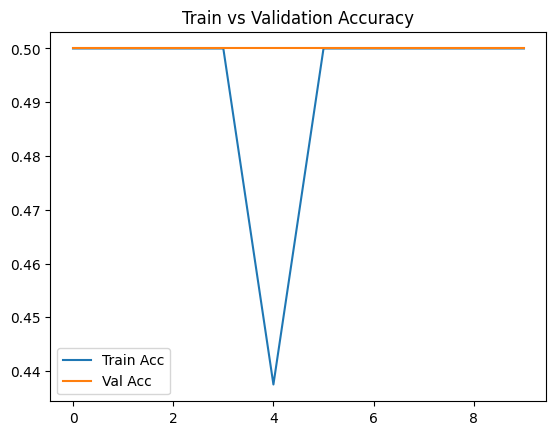

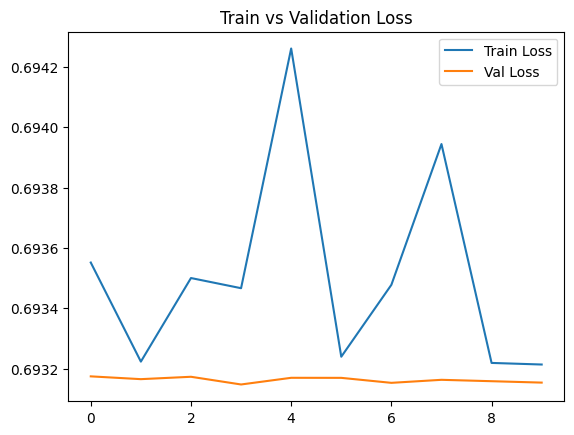

In [2]:
# Q13 - Overfitting check using existing trained model (no re-initialization)

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import torch

# ---- 1) Split existing X, y into train/val ----
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

class SentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SentDataset(X_train, y_train), batch_size=8, shuffle=True)
val_loader = DataLoader(SentDataset(X_val, y_val), batch_size=8, shuffle=False)

# ---- 2) Track metrics ----
epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

def evaluate(loader):
    model.eval()
    total_loss, total_correct, total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss/total, total_correct/total

for ep in range(epochs):
    model.train()
    total_loss, total_correct, total = 0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == yb).sum().item()
        total += xb.size(0)

    train_loss = total_loss/total
    train_acc = total_correct/total

    val_loss, val_acc = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {ep+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

# ---- 3) Plot ----
plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Train vs Validation Accuracy")
plt.show()

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Train vs Validation Loss")
plt.show()

### Answer Q13:


The training and validation accuracies both remain around 0.50 across all epochs, and the training and validation losses stay close to 0.693 without significant divergence. Since there is no gap between train and validation performance and both remain at chance level, the RNN does not overfit; instead, it underfits and fails to learn meaningful patterns from the data.

## Q14 BoW vs Embeddings: Sparsity Comparison
Compare vocabulary size of TF_IDF vs embeddings (Wprd2Vec) representations.
Explain sparsity difference numerically.

Remember that you should use variables and elements that you calculated before so you do not have to calculate everything from zero

### Answer Q14:


# Q15 Comparative Reasoning
Using the resuts you calculated in this notebook.
Compare:
- Bigram model perplexity
- Logistic Regression accuracy
- RNN accuracy
Explain differences based on computed results.

### Answer Q15:
